In [1]:
import numpy as np
import os
import torch
import pickle

from collections import defaultdict

from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from loguru import logger
from tqdm import tqdm

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

from Tracklet import Tracklet

import argparse
from copy import copy
import shutil
import cv2 as cv
from collections import defaultdict
import random
import cv2

In [2]:
from merge_tracklets_groups import(
    get_distance_matrix, get_distance, get_spatial_constraints,
    split_tracklets, merge_tracklets, save_results
)

In [3]:
# seq_tracks_dir="F:\\Dataset\\test_merge_videos_tracklets\\seq_temporal"
seq_tracks_dir="F:\\Dataset\\test_merge_videos_tracklets\\seq_split&merged"

In [4]:
seqs_tracks = os.listdir(seq_tracks_dir)
seqs_tracks.sort()
seqs_tracks

['seq_1.pkl', 'seq_2.pkl']

In [5]:
tracklets_spartial = {}

for seq_idx, seq in enumerate(seqs_tracks):
    seq_idx = int(seq_idx)

    seq_name = seq.split('.')[0] 
    logger.info(f"Processing seq {seq_idx+1} / {len(seqs_tracks)}")
    with open(os.path.join(seq_tracks_dir, seq), 'rb') as pkl_f:
        tmp_trklets = pickle.load(pkl_f)     # dict(key:track id, value:tracklet)

    tracklets_spartial[seq_idx] = {
        "tracklets": tmp_trklets, 
        "time_delta":max([max(tracklet.times) for _,tracklet in tmp_trklets.items()]),
        "max_trackid": max(tmp_trklets.keys()),
    }

2025-07-26 02:34:52.604 | INFO     | __main__:<module>:7 - Processing seq 1 / 2
2025-07-26 02:34:53.530 | INFO     | __main__:<module>:7 - Processing seq 2 / 2


## Calculate distances between tracklet embeddings

In [8]:
def get_cross_distance_matrix(tid2track1, tid2track2):
    """
    Constructs and returns a distance matrix between all tracklets based on overlapping times and feature similarities.

    Args:
        tid2track (dict): Dictionary mapping track IDs to their respective track objects.

    Returns:
        ndarray: A square matrix where each element (i, j) represents the calculated distance between track i and track j.
    """
    # print("number of tracks:", len(tid2track))
    Dist = np.zeros((len(tid2track1), len(tid2track2)))

    for i, (track1_id, track1) in enumerate(tid2track1.items()):
        assert len(track1.times) == len(track1.bboxes)
        for j, (track2_id, track2) in enumerate(tid2track2.items()):
            Dist[i][j] = get_distance(track1_id, track2_id, track1, track2)
    return Dist

In [43]:
len(tracklets_spartial[0]['tracklets']), len(tracklets_spartial[1]['tracklets'])

(64, 72)

In [44]:
np.unique(tracklets_spartial[0]['tracklets'].keys()), np.unique(tracklets_spartial[1]['tracklets'].keys())

(array([dict_keys([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 42.0, 44.0, 46.0, 47.0, 48.0, 49.0, 50.0, 52.0, 53.0, 9.0, 43.0, 54.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 45.0, 51.0, 20.0, 55.0, 21.0, 22.0, 56.0, 23.0, 24.0, 25.0, 26.0, 27.0, 58.0, 28.0, 61.0, 62.0, 29.0, 60.0, 63.0, 30.0, 31.0, 64.0, 59.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 57.0, 39.0, 40.0, 41.0])],
       dtype=object),
 array([dict_keys([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 48.0, 49.0, 50.0, 53.0, 55.0, 57.0, 58.0, 59.0, 52.0, 54.0, 60.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 61.0, 51.0, 62.0, 15.0, 56.0, 16.0, 63.0, 65.0, 17.0, 67.0, 64.0, 18.0, 19.0, 20.0, 21.0, 68.0, 69.0, 22.0, 66.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 70.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 71.0, 72.0, 47.0])],
       dtype=object))

In [45]:
tracklets_spartial[0]['max_trackid'], tracklets_spartial[1]['max_trackid']

(64.0, 72.0)

In [46]:
dist_groups =  get_cross_distance_matrix(
    tracklets_spartial[0]['tracklets'],
    tracklets_spartial[1]['tracklets'],
)

<Axes: >

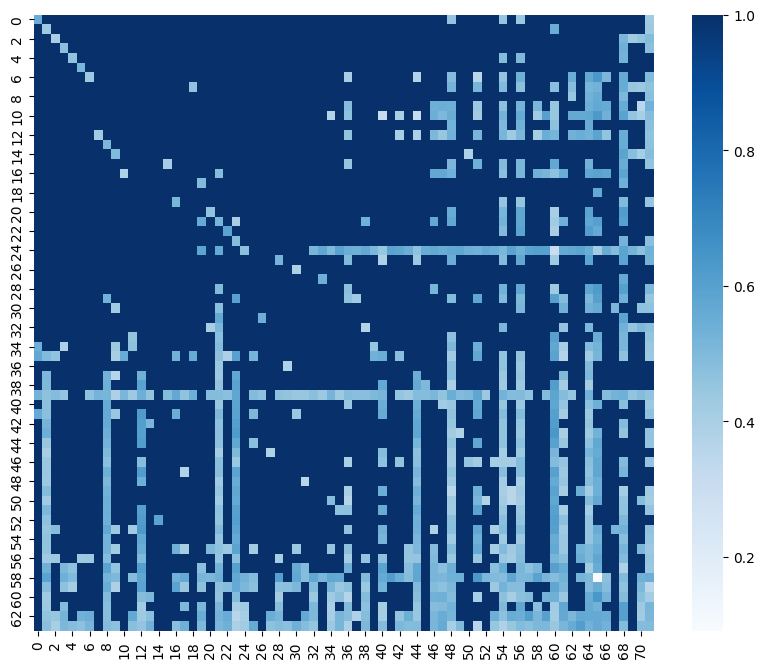

In [47]:
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(dist_groups, cmap='Blues')

In [48]:
tracklets_spartial[0]['time_delta'], tracklets_spartial[1]['time_delta']

(1773.0, 1749.0)

In [49]:
# (np.asarray(tracklets_spartial[0]['tracklets'][1.0].times) + 200).tolist()

Two variants:
1. add to times of second tracklets group max delta of the first groupr and give second tracklets numbers larger
2. perform merge of ends of first group tracklet's ends and starts of second group.

In [50]:
all_tracklets = {}
time_thresh = 100
glob_id = 0
time_delta = 0.0
for _, value in tracklets_spartial.items():
    last_tracklets_time = value['time_delta']
    for id, trk in value['tracklets'].items():
        trk_times = trk.times
        trk_max_time = max(trk_times)
        if trk_max_time >= last_tracklets_time - time_thresh:
            # tracklet is ended with video, so add it for merging:
            all_tracklets[glob_id] = trk
            all_tracklets[glob_id].track_id = glob_id
            all_tracklets[glob_id].times = (np.asarray(trk_times) + time_delta).tolist()
            glob_id += 1
    time_delta += last_tracklets_time
    

In [51]:
len(all_tracklets)

88

In [52]:
spatial_factor = 1
min_len = 100
eps = 0.7
min_samples = 10
max_k = 3
merge_dist_thres = 0.4

In [53]:
max_x_range, max_y_range = get_spatial_constraints(all_tracklets, spatial_factor)

In [54]:
Dist = get_distance_matrix(all_tracklets)

In [55]:
seq2Dist = dict()
seq2Dist[seq_name] = Dist

<Axes: >

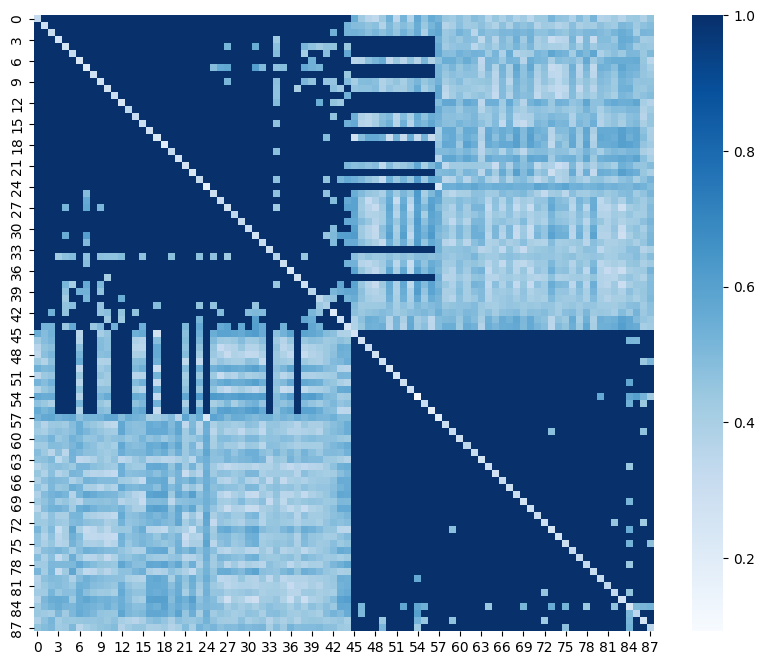

In [56]:
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(Dist, cmap='Blues')

In [57]:
splitTracklets = split_tracklets(
    all_tracklets, eps=eps, max_k=max_k, min_samples=min_samples, len_thres=min_len)

Splitting tracklets: 100%|██████████| 88/88 [00:01<00:00, 87.34it/s]


In [58]:
len(splitTracklets)

97

In [59]:
Dist = get_distance_matrix(splitTracklets)

<Axes: >

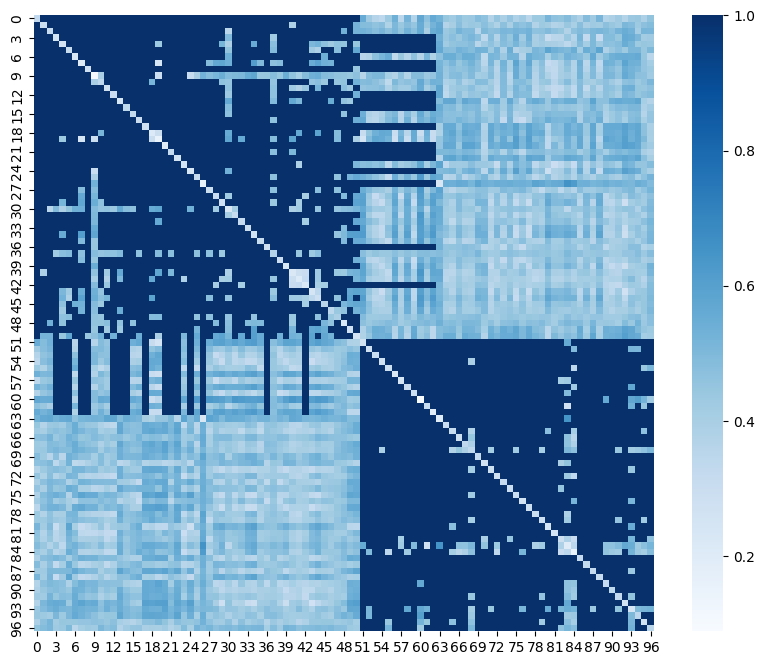

In [60]:
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(Dist, cmap='Blues')

In [61]:
mergedTracklets = merge_tracklets(
    splitTracklets, 
    seq2Dist, 
    Dist, 
    seq_name=seq_name,
    max_x_range=max_x_range, 
    max_y_range=max_y_range, 
    merge_dist_thres=merge_dist_thres
)

----------------Number of tracklets after merging: 52----------------


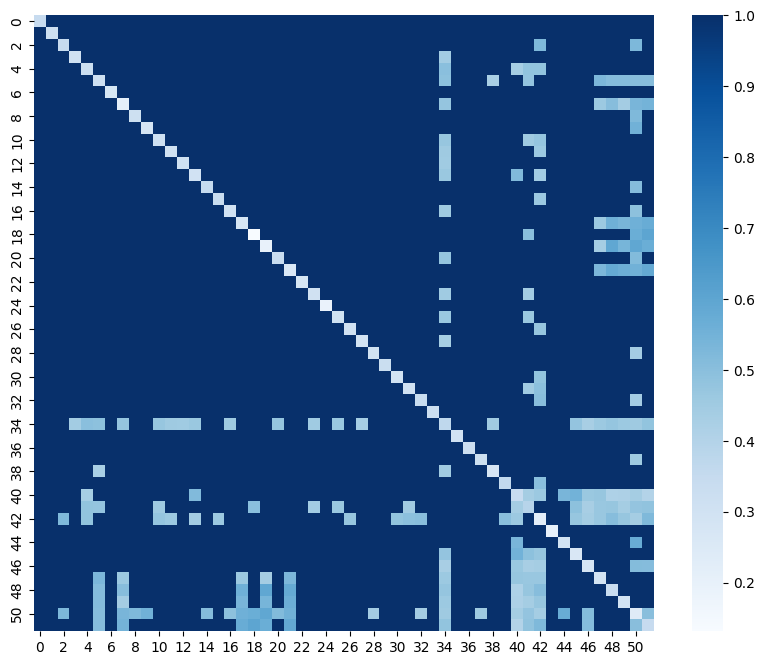

In [62]:
Dist = get_distance_matrix(mergedTracklets)
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(Dist, cmap='Blues')
print(f"----------------Number of tracklets after merging: {len(mergedTracklets)}----------------")

In [63]:
# def save_results(sct_output_path, tracklets):
#     """
#     Saves the final tracklet results into a specified path.

#     Args:
#         sct_output_path (str): Path where the results will be saved.
#         tracklets (dict): Dictionary of tracklets containing their final states.

#     """
#     results = []

#     for i, tid in enumerate(sorted(tracklets.keys())): # add each track to results
#         track = tracklets[tid]
#         tid = i + 1
#         for instance_idx, frame_id in enumerate(track.times):
#             bbox = track.bboxes[instance_idx]
            
#             results.append(
#                 [frame_id, tid, bbox[0], bbox[1], bbox[2], bbox[3], 1, -1, -1, -1]
#             )
#     results = sorted(results, key=lambda x: x[0])
#     txt_results = []
#     for line in results:
#         txt_results.append(
#             f"{line[0]},{line[1]},{line[2]:.2f},{line[3]:.2f},{line[4]:.2f},{line[5]:.2f},{line[6]},{line[7]},{line[8]},{line[9]}\n"
#             )
    
#     # NOTE: uncomment to save results
#     with open(sct_output_path, 'w') as f:
#         f.writelines(txt_results)
#     logger.info(f"save SCT results to {sct_output_path}")

In [64]:
def copy_and_rename_images(src_dirs, output_dir, tracklets_spartial):
    os.makedirs(output_dir, exist_ok=True)
    delta = 0.0
    for i, src_dir in enumerate(src_dirs):        
        for img_name in os.listdir(src_dir):
            # Extract numeric part and convert to float
            base, ext = os.path.splitext(img_name)
            try:
                img_num = float(base)
            except ValueError:
                continue  # skip non-numeric filenames
            new_img_num = img_num + delta
            new_img_name = f"{new_img_num:.1f}{ext}"
            src_path = os.path.join(src_dir, img_name)
            dst_path = os.path.join(output_dir, new_img_name)
            shutil.copy2(src_path, dst_path)
        delta += tracklets_spartial[i]['time_delta']

In [65]:
save_results("F:\\Dataset\\test_merge_videos_tracklets\\seq_merged.txt", mergedTracklets)

2025-07-24 17:40:23.397 | INFO     | merge_tracklets_groups:save_results:649 - save SCT results to F:\Dataset\test_merge_videos_tracklets\seq_merged.txt


In [66]:
IMG_DIR1 = "F:\\Dataset\\test_merge_videos_tracklets\\part1\\outputs\\seq_0\\img1"
IMG_DIR2 = "F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1"
OUTPUT_DIR = "F:\\Dataset\\test_merge_videos_tracklets\\merged_images"

In [67]:
<!-- copy_and_rename_images([IMG_DIR1, IMG_DIR2], OUTPUT_DIR, tracklets_spartial) -->

SyntaxError: invalid syntax (2374687949.py, line 1)

### 2. Try to find close tracklets

In [6]:
def plot_trajectory(tracklet):
    """
    Plots the trajectory of an object from its tracklet data.
    
    Parameters:
    tracklet (list of lists): Each inner list is a bounding box [x, y, width, height].
    """
    # Extract center coordinates (x, y) for each bounding box
    centers_x = []
    centers_y = []
    
    for bbox in tracklet:
        x, y, w, h = bbox
        center_x = x + w / 2  # Calculate center x-coordinate
        center_y = y + h / 2  # Calculate center y-coordinate
        centers_x.append(center_x)
        centers_y.append(center_y)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(centers_x, centers_y, 'bo-', linewidth=2, markersize=8, label='Trajectory')  # Blue line with circle markers
    plt.scatter(centers_x[0], centers_y[0], color='green', s=100, zorder=5, label='Start')  # Green dot for start
    plt.scatter(centers_x[-1], centers_y[-1], color='red', s=100, zorder=5, label='End')    # Red dot for end
    
    plt.title('Object Trajectory', fontsize=14)
    plt.xlabel('X-coordinate (pixels)', fontsize=12)
    plt.ylabel('Y-coordinate (pixels)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.gca().invert_yaxis()  # Match image coordinate system (origin at top-left)
    plt.tight_layout()
    plt.show()

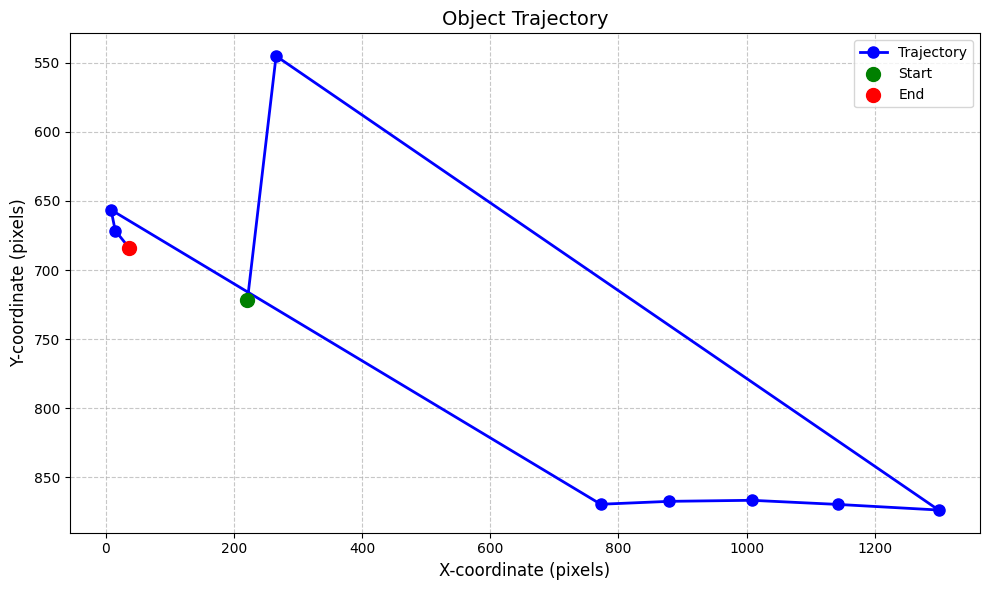

In [ ]:
plot_trajectory(tracklets_spartial[1]['tracklets'][30.0].bboxes[-10:])

In [6]:
def calculate_bbox_distance(bbox1: List[float], bbox2: List[float]) -> float:
    """Calculate Euclidean distance between two bounding box centers"""
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    
    # Calculate centers
    center1_x = x1 + w1 / 2
    center1_y = y1 + h1 / 2
    center2_x = x2 + w2 / 2
    center2_y = y2 + h2 / 2
    
    return np.sqrt((center1_x - center2_x)**2 + (center1_y - center2_y)**2)

In [7]:
def calculate_bbox_overlap(bbox1: List[float], bbox2: List[float]) -> float:
    """Calculate IoU (Intersection over Union) between two bounding boxes"""
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    
    # Calculate intersection
    left = max(x1, x2)
    top = max(y1, y2)
    right = min(x1 + w1, x2 + w2)
    bottom = min(y1 + h1, y2 + h2)
    
    if left < right and top < bottom:
        intersection = (right - left) * (bottom - top)
    else:
        intersection = 0
    
    # Calculate union
    area1 = w1 * h1
    area2 = w2 * h2
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

In [8]:
# time_window1 = 1
# time_window2 = 1
# correspondence_map = {}
    
# for id1, tracklet1 in tracklets_spartial[0]['tracklets'].items():
#     if not tracklet1.times:
#         continue
        
#     # Get the last few bounding boxes from video1
#     end_indices = max(0, len(tracklet1.times) - time_window1)
#     end_bboxes1 = tracklet1.bboxes[end_indices:]
    
#     best_match_id = None
#     best_score = 0
        
#     for id2, tracklet2 in tracklets_spartial[1]['tracklets'].items():
#         if not tracklet2.times:
#             continue
            
#         # Get the first few bounding boxes from video2
#         start_bboxes2 = tracklet2.bboxes[:min(time_window2, len(tracklet2.bboxes))]
        
#         # Calculate similarity scores between end of tracklet1 and start of tracklet2
#         total_score = 0
#         comparisons = 0
            
#         for bbox1 in end_bboxes1:
#             for bbox2 in start_bboxes2:
#                 distance = calculate_bbox_distance(bbox1, bbox2)
#                 overlap = calculate_bbox_overlap(bbox1, bbox2)
                
#                 if distance < distance_threshold and overlap > overlap_threshold:
#                     # Combine distance and overlap into a single score
#                     score = overlap * (1 - distance / distance_threshold)
#                     total_score += score
#                     comparisons += 1
        

In [8]:
def get_closest_tracklets(start_tracklets, end_tracklets, start_window=1, end_window=1):
    start_bboxes = []
    start_track_ids = []
    start_delta = start_tracklets['time_delta'] - start_window    
    for track_id, tracklet in start_tracklets['tracklets'].items():
        ids = np.nonzero(tracklet.times > start_delta)[0]
        if ids.shape[0] > 0:
            start_bboxes.append(np.asarray(tracklet.bboxes)[ids])
            start_track_ids.append(track_id)
    start_track_ids = np.asarray(start_track_ids)
    start_bboxes = np.vstack(start_bboxes)

    end_bboxes = []
    end_track_ids = []
    end_delta = np.float64(end_window)
    for track_id, tracklet in end_tracklets['tracklets'].items():
        ids = np.nonzero(tracklet.times < end_delta)[0][-1:]
        if ids.shape[0] > 0:
            end_bboxes.append(np.asarray(tracklet.bboxes)[ids])
            end_track_ids.append(track_id)
    end_track_ids = np.asarray(end_track_ids)
    end_bboxes = np.vstack(end_bboxes)     

    overlap = np.zeros((start_bboxes.shape[0], end_bboxes.shape[0]))
    for i, bbox0 in enumerate(start_bboxes):
        for j, bbox1 in enumerate(end_bboxes):
            overlap[i,j] = calculate_bbox_overlap(bbox0, bbox1)    

    return overlap, start_track_ids, end_track_ids

In [9]:
def get_closest_tracklets_full_matrix(
        start_tracklets, 
        end_tracklets,
        start_window=1, 
        end_window=1,
    ):
    overlap = np.zeros((len(start_tracklets['tracklets']), len(end_tracklets['tracklets'])))

    start_bboxes = {}
    start_delta = start_tracklets['time_delta'] - start_window    
    for track_id, tracklet in start_tracklets['tracklets'].items():
        ids = np.nonzero(tracklet.times > start_delta)[0]
        if ids.shape[0] > 0:
            if track_id not in start_bboxes:
                start_bboxes[track_id] = np.asarray(tracklet.bboxes)[ids]
            else:
                start_bboxes[track_id] = np.vstack((start_bboxes[track_id], np.asarray(tracklet.bboxes)[ids]))    

    end_bboxes = {}
    end_delta = np.float64(end_window)
    for track_id, tracklet in end_tracklets['tracklets'].items():
        ids = np.nonzero(tracklet.times < end_delta)[0][-1:]
        if ids.shape[0] > 0:
            if track_id not in end_bboxes:
                end_bboxes[track_id] = np.asarray(tracklet.bboxes)[ids]
            else:
                end_bboxes[track_id] = np.vstack((end_bboxes[track_id], np.asarray(tracklet.bboxes)[ids]))  
    
    overlap = np.zeros((len(start_bboxes), len(end_bboxes)))

    # Get sorted lists of keys for consistent indexing
    start_keys = sorted(start_bboxes.keys())
    end_keys = sorted(end_bboxes.keys())

    # Create mapping from key to index
    start_tracklet2id = {key: i for i, key in enumerate(start_keys)}
    end_tracklet2id = {key: i for i, key in enumerate(end_keys)}

    for start_id, bbox0 in start_bboxes.items():
        for end_id, bbox1 in end_bboxes.items():
            i = start_tracklet2id[start_id]
            j = end_tracklet2id[end_id]
            overlap[i,j] = calculate_bbox_overlap(bbox0[0], bbox1[0])    # Take first bbox if multiple

    return (
        overlap, 
        start_bboxes, 
        end_bboxes, 
        start_tracklet2id, 
        end_tracklet2id,
    )

In [11]:
# start_tracklet2id = {track_id: i for i, track_id in enumerate(tracklets_spartial[0]['tracklets'].keys())}
# end_tracklet2id = {track_id: i for i, track_id in enumerate(tracklets_spartial[1]['tracklets'].keys())}

In [11]:
# overlap = get_closest_tracklets_full_matrix(
#     tracklets_spartial[0], 
#     start_tracklet2id,
#     tracklets_spartial[1],
#     end_tracklet2id,
#     start_window=1, 
#     end_window=1
# )

In [14]:
def find_closest_tracklets_mapping(
    start_tracklets, 
    end_tracklets, 
    max_start_window=5, 
    max_end_window=5,
    max_overlap_threshold=0.9,
    ):

    best_mapping = {}
    best_overlaps = {}
    best_start_window = 1
    best_end_window = 1
    # Initialize with defaultdicts
    best_start_bboxes = defaultdict(list)
    best_end_bboxes = defaultdict(list)
    
    # Try different window sizes to find best matches
    for start_window in range(1, max_start_window + 1):
        for end_window in range(1, max_end_window + 1):
            # Get closest tracklets with current windows
            (overlap_matrix, 
             start_bboxes, 
             end_bboxes, 
             start_tracklet2id, 
             end_tracklet2id
            ) = get_closest_tracklets_full_matrix(
                start_tracklets, 
                end_tracklets,
                start_window=start_window, 
                end_window=end_window,
            )
            start_id2tracklet = {i: track_id for track_id, i in start_tracklet2id.items()}
            end_id2tracklet = {i: track_id for track_id, i in end_tracklet2id.items()}

            # Update best mappings if we find better overlaps
            for i in range(overlap_matrix.shape[0]):
                start_id = start_id2tracklet[i]
                max_overlap = np.max(overlap_matrix[i])
                
                # Only consider mappings with significant overlap
                if max_overlap > max_overlap_threshold:  # You can adjust this threshold
                    if start_id not in best_overlaps or max_overlap > best_overlaps[start_id]:                        
                        # Get the track ID from end_tracklets that corresponds to this match
                        matched_idx = np.argmax(overlap_matrix[i])
                        end_track_id = end_id2tracklet[matched_idx]
                        # save mapping
                        if end_track_id in best_mapping.values():
                            continue
                        best_overlaps[start_id] = max_overlap
                        best_mapping[start_id] = end_track_id
                        # window sizes with maximum intersection
                        best_start_window = start_window
                        best_end_window = end_window
                        # append new boxes to the best bboxes
                        best_start_bboxes[start_id].append(start_bboxes[start_id])
                        best_end_bboxes[end_track_id].append(end_bboxes[end_track_id])
    # After the loop, convert to arrays
    best_start_bboxes = {
        track_id: np.concatenate(bbox_list, axis=0) 
        for track_id, bbox_list in best_start_bboxes.items()
    }
    best_end_bboxes = {
        track_id: np.concatenate(bbox_list, axis=0) 
        for track_id, bbox_list in best_end_bboxes.items()
    }
    return best_mapping, best_overlaps, best_start_window, best_end_window, best_start_bboxes, best_end_bboxes

# Find the best matches
mapping, overlaps, best_start_window, best_end_window, best_start_bboxes, best_end_bboxes = find_closest_tracklets_mapping(
    tracklets_spartial[0], tracklets_spartial[1], max_start_window=15, max_end_window=15)

# Print results
for start_id, end_id in mapping.items():
    print(f"Track {start_id} matches with track {end_id} (overlap: {overlaps[start_id]:.3f})")

print(f"Unique start tracklets: {len(list(mapping.keys()))} Unique end tracklets: {len(list(mapping.values()))}")

Track 51.0 matches with track 48.0 (overlap: 1.000)
Track 7.0 matches with track 2.0 (overlap: 0.909)
Track 15.0 matches with track 57.0 (overlap: 0.908)
Track 10.0 matches with track 49.0 (overlap: 0.982)
Track 8.0 matches with track 58.0 (overlap: 1.000)
Track 9.0 matches with track 50.0 (overlap: 1.000)
Track 12.0 matches with track 59.0 (overlap: 1.000)
Track 13.0 matches with track 8.0 (overlap: 1.000)
Track 18.0 matches with track 1.0 (overlap: 1.000)
Track 31.0 matches with track 10.0 (overlap: 1.000)
Track 42.0 matches with track 5.0 (overlap: 1.000)
Track 46.0 matches with track 53.0 (overlap: 1.000)
Track 47.0 matches with track 4.0 (overlap: 1.000)
Track 52.0 matches with track 60.0 (overlap: 1.000)
Track 53.0 matches with track 3.0 (overlap: 1.000)
Track 62.0 matches with track 55.0 (overlap: 1.000)
Track 48.0 matches with track 7.0 (overlap: 1.000)
Track 1.0 matches with track 6.0 (overlap: 1.000)
Track 27.0 matches with track 9.0 (overlap: 1.000)
Unique start tracklets: 1

In [ ]:
best_end_bboxes[10.0]

array([[1196.12,  475.04,   18.98,   51.56]])

In [ ]:
# tracklets_spartial[0]['tracklets'][1.0].times, tracklets_spartial[0]['tracklets'][1.0].bboxes

In [ ]:
best_start_bboxes.keys(), best_end_bboxes.keys()

(dict_keys([51.0, 7.0, 15.0, 10.0, 8.0, 9.0, 12.0, 13.0, 18.0, 31.0, 42.0, 46.0, 47.0, 52.0, 53.0, 62.0, 48.0, 1.0, 27.0]),
 dict_keys([48.0, 54.0, 2.0, 57.0, 58.0, 50.0, 59.0, 8.0, 1.0, 10.0, 5.0, 52.0, 4.0, 60.0, 3.0, 55.0, 7.0, 6.0, 49.0, 9.0, 53.0]))

In [ ]:
best_start_window, best_end_window

(14, 1)

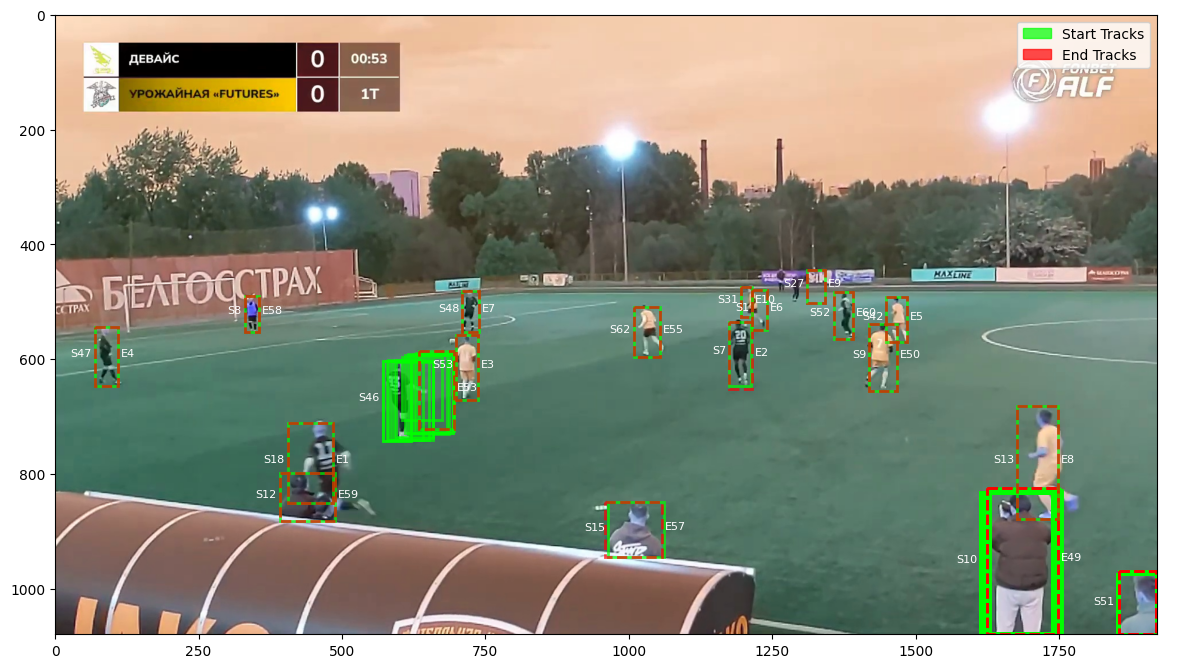

In [15]:
def draw_bboxes(back_img, start_bboxes, end_bboxes, mapping=None):
    """
    Draw bounding boxes with track IDs showing the mapping between start and end tracks
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(back_img)
    
    # Set reasonable colors
    start_color = 'lime'
    end_color = 'red'
    text_color = 'white'
    alpha = 0.7

    # Create legend elements
    legend_elements = [
        patches.Patch(color=start_color, label='Start Tracks', alpha=alpha),
        patches.Patch(color=end_color, label='End Tracks', alpha=alpha)
    ]

    # Single loop over mapping to draw both start and end bboxes
    for start_id, end_id in mapping.items():
        # Draw start bbox
        if start_id in start_bboxes:
            bboxes = start_bboxes[start_id]
            for bbox in bboxes:
                x,y,w,h = bbox
                rect = patches.Rectangle(
                    (x,y), w, h,
                    linewidth=2, edgecolor=start_color, facecolor='none',
                    linestyle='-', alpha=alpha
                )
                ax.add_patch(rect)
            x,y,w,h = bboxes[0]
            ax.text(x-5, y+h/2, f'S{int(start_id)}', color=text_color,
                    fontsize=8, horizontalalignment='right')

        # Draw end bbox
        if end_id in end_bboxes:
            bboxes = end_bboxes[end_id]
            for bbox in bboxes:
                x,y,w,h = bbox
                rect = patches.Rectangle(
                    (x,y), w, h,
                    linewidth=2, edgecolor=end_color, facecolor='none',
                    linestyle='--', alpha=alpha
                )
                ax.add_patch(rect)
            x,y,w,h = bboxes[0]
            ax.text(x+w+5, y+h/2, f'E{int(end_id)}', color=text_color,
                    fontsize=8, horizontalalignment='left')
            # print(start_id, end_id)
    
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.show()

bkg_image_id = abs(best_start_window - best_end_window-1)
bkg_img = cv.imread(f"F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1\\{bkg_image_id:06d}.jpg")
draw_bboxes(bkg_img, best_start_bboxes, best_end_bboxes, mapping)

In [185]:
print(mapping)

{51.0: 48.0, 7.0: 2.0, 15.0: 57.0, 10.0: 49.0, 8.0: 58.0, 9.0: 50.0, 12.0: 59.0, 13.0: 8.0, 18.0: 1.0, 31.0: 10.0, 42.0: 5.0, 46.0: 53.0, 47.0: 4.0, 52.0: 60.0, 53.0: 3.0, 62.0: 55.0, 48.0: 7.0, 1.0: 6.0, 27.0: 9.0}


In [13]:
existing_ids = set(tracklets_spartial[1]['tracklets'].keys())
print(existing_ids)

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0}


In [14]:
new_mapped_ids = set(mapping.keys())
print(new_mapped_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 12.0, 13.0, 15.0, 18.0, 27.0, 31.0, 42.0, 46.0, 47.0, 48.0, 51.0, 52.0, 53.0, 62.0}


In [15]:
old_mapped_ids = set(mapping.values())
print(old_mapped_ids)

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 48.0, 49.0, 50.0, 53.0, 55.0, 57.0, 58.0, 59.0, 60.0}


In [16]:
old_mapped_ids.intersection(new_mapped_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 48.0, 53.0}

In [17]:
#Ids of tracklets, which are in changed tracklets conflicting with new tracklets
conflict_ids = existing_ids.intersection(new_mapped_ids)
print(conflict_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 12.0, 13.0, 15.0, 18.0, 27.0, 31.0, 42.0, 46.0, 47.0, 48.0, 51.0, 52.0, 53.0, 62.0}


In [18]:
old_mapped_ids.intersection(conflict_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 48.0, 53.0}

In [46]:
not_changed_ids = existing_ids - old_mapped_ids - conflict_ids
print(not_changed_ids)

{11.0, 14.0, 16.0, 17.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 28.0, 29.0, 30.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 43.0, 44.0, 45.0, 54.0, 56.0, 61.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0}


In [137]:
equal_ids = set([k for k, v in mapping.items() if k == v]) 

In [138]:
equal_ids

set()

In [80]:
# here we gather all new tracklets
new_tracklets_dict = {
    'tracklets': {},
    'time_delta': tracklets_spartial[1]['time_delta'],
    'max_trackid': tracklets_spartial[1]['max_trackid']
}

In [81]:
## after this step all old_ids will be replaced with new_ids and corresponding tracks are used
reverse_mapping = {v: k for k, v in mapping.items()}
# here we put all tracklets, wich wer changed
rewritten_tracklets = {}
old_new_intersection = old_mapped_ids.intersection(new_mapped_ids)

for old_id in old_mapped_ids:
    new_id = reverse_mapping[old_id]
    new_tracklet = tracklets_spartial[1]['tracklets'][old_id]
    new_tracklet = copy(new_tracklet)
    new_tracklet.track_id = new_id

    if (new_id != old_id) and (old_id not in old_new_intersection):
        old_tracklet = tracklets_spartial[1]['tracklets'][new_id]
        old_tracklet = copy(old_tracklet)
        old_tracklet.track_id = old_id
        rewritten_tracklets[old_id] = old_tracklet

    new_tracklets_dict['tracklets'][new_id] = new_tracklet         

In [82]:
for track_id, tracklet in tracklets_spartial[1]['tracklets'].items():
    if (track_id not in old_mapped_ids) and (track_id not in new_mapped_ids):
        new_tracklets_dict['tracklets'][track_id] = copy(tracklet)
        new_tracklets_dict['tracklets'][track_id].track_id = track_id

In [74]:
len(existing_ids.difference(new_tracklets_dict['tracklets'].keys())), len(new_tracklets_dict['tracklets'].keys())

(12, 60)

In [83]:
not_used_ids = list(existing_ids.difference(new_tracklets_dict['tracklets'].keys()))
assert len(not_used_ids) == len(rewritten_tracklets), \
    f"Not enough elements in not_used_ids: {len(not_used_ids)} to assign"
for _, tracklet in rewritten_tracklets.items():
    track_id = not_used_ids.pop(0)
    new_tracklets_dict['tracklets'][track_id] = copy(tracklet)
    new_tracklets_dict['tracklets'][track_id].track_id = track_id

In [77]:
len(new_tracklets_dict['tracklets'])

72

In [ ]:
old_mapped_ids.intersection(new_mapped_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 48.0, 53.0}

In [63]:
41 + 19 + 19 -7

72

In [163]:
assert set(new_tracklets_dict['tracklets'].keys()) == new_mapped_ids
print("OK")

OK


In [170]:
union_new_old = new_mapped_ids.union(old_mapped_ids)

In [183]:
len(new_mapped_ids.intersection(old_mapped_ids))

7

In [ ]:
print(len(existing_ids.difference(union_new_old)))

41


In [179]:
len(existing_ids.difference(old_mapped_ids))

53

In [177]:
print(union_new_old.difference(existing_ids))

set()


In [ ]:
remaining_ids = old_mapped_ids.difference(new_mapped_ids)
print(len(remaining_ids))

{2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0}


In [158]:
print(new_mapped_ids.difference(old_mapped_ids))

{42.0, 12.0, 13.0, 46.0, 15.0, 47.0, 18.0, 51.0, 52.0, 27.0, 62.0, 31.0}


In [159]:
print(old_mapped_ids.difference(new_mapped_ids))

{2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0}


In [142]:
for track_id, tracklet in tracklets_spartial[1]['tracklets'].items():
    if (track_id not in old_mapped_ids) and (track_id not in new_mapped_ids):
        new_tracklets_dict['tracklets'][track_id] = tracklet

In [29]:
new_tracklets_dict['tracklets'].keys()

dict_keys([18.0, 7.0, 53.0, 47.0, 42.0, 1.0, 48.0, 13.0, 27.0, 31.0, 51.0, 10.0, 9.0, 46.0, 62.0, 15.0, 8.0, 12.0, 52.0, 54.0, 11.0, 14.0, 61.0, 56.0, 16.0, 63.0, 65.0, 17.0, 67.0, 64.0, 19.0, 20.0, 21.0, 68.0, 69.0, 22.0, 66.0, 23.0, 24.0, 25.0, 26.0, 28.0, 29.0, 30.0, 32.0, 33.0, 34.0, 35.0, 36.0, 70.0, 37.0, 38.0, 39.0, 40.0, 41.0, 43.0, 44.0, 45.0, 71.0, 72.0])

In [30]:
set(new_tracklets_dict['tracklets'].keys()).intersection(old_mapped_ids)

{1.0, 7.0, 8.0, 9.0, 10.0, 48.0, 53.0}

In [134]:
old_mapped_ids.difference(set(new_tracklets_dict['tracklets'].keys()))

{2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0}

In [135]:
print(existing_ids.difference(set(new_tracklets_dict['tracklets'].keys())))

{2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0}


In [136]:
remaining_ids = old_mapped_ids.difference(new_mapped_ids)
print(remaining_ids)

{2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0}


In [ ]:
for new_id in new_mapped_ids:
        new_id = mapping[conflict_id]
        if new_id in tracklets_spartial[1]['tracklets']:
            tracklet = tracklets_spartial[1]['tracklets'][new_id]
            new_tracklet = copy(tracklet)
            new_tracklet.track_id = new_id
            new_tracklets_dict['tracklets'][new_id] = new_tracklet

In [143]:
len(new_tracklets_dict['tracklets'].keys())

72

In [16]:
def replace_tracklet_keys(tracklets, mapping):
    # Create a new dictionary with the same structure
    new_tracklets = {}    
    # Get all existing track IDs
    existing_ids = set(tracklets.keys())
    # Mapped tracklets
    new_mapped_ids = set(mapping.keys())
    # non-conflict ids
    old_mapped_ids = set(mapping.values())    
    
    reverse_mapping = {v: k for k, v in mapping.items()}
    old_new_intersection = old_mapped_ids.intersection(new_mapped_ids)
    rewritten_tracklets = []

    for old_id in old_mapped_ids:
        new_id = reverse_mapping[old_id]
        if (new_id != old_id) and (old_id not in old_new_intersection):
            old_tracklet = copy(tracklets[new_id])
            old_tracklet.track_id = None
            rewritten_tracklets.append(old_tracklet)
        new_tracklet = copy(tracklets[old_id])
        new_tracklet.track_id = new_id
        new_tracklets[new_id] = new_tracklet   
    
    # Copy non-mapped tracklets from original dict
    old_new_union = old_mapped_ids.union(new_mapped_ids)
    for track_id, tracklet in tracklets.items():
        if track_id not in old_new_union:
            new_tracklets[track_id] = copy(tracklet)
            new_tracklets[track_id].track_id = track_id
    
    not_used_ids = list(existing_ids.difference(new_tracklets.keys()))
    assert len(not_used_ids) == len(rewritten_tracklets), \
        f"Not enough elements in not_used_ids: {len(not_used_ids)} to assign"
    
    print(not_used_ids)
    print(rewritten_tracklets)
    for tracklet in rewritten_tracklets:
        track_id = not_used_ids.pop(0)
        new_tracklets[track_id] = copy(tracklet)
        new_tracklets[track_id].track_id = track_id
        print(new_tracklets[track_id].track_id)

    return new_tracklets

# Apply the remapping
# new_tracklets_dict = remap_track_ids(tracklets_spartial[1], mapping)

In [ ]:
# #compare new and original tracklets by bbiboxes and times
# after_processing_ids = set()
# for track_id, tracklet in new_tracklets_dict['tracklets'].items():
#     if track_id in tracklets_spartial[1]['tracklets']:
#         original_tracklet = tracklets_spartial[1]['tracklets'][track_id]
#         if ( not np.array_equal(tracklet.bboxes, original_tracklet.bboxes) 
#             and not np.array_equal(tracklet.times, original_tracklet.times)):
#             after_processing_ids.add(track_id)
#             print(f"Track ID {track_id} has different times or bboxes after remapping.")

# assert after_processing_ids == new_mapped_ids
# print("Mapping correct.")

Track ID 18.0 has different times or bboxes after remapping.
Track ID 7.0 has different times or bboxes after remapping.
Track ID 53.0 has different times or bboxes after remapping.
Track ID 47.0 has different times or bboxes after remapping.
Track ID 42.0 has different times or bboxes after remapping.
Track ID 1.0 has different times or bboxes after remapping.
Track ID 48.0 has different times or bboxes after remapping.
Track ID 13.0 has different times or bboxes after remapping.
Track ID 27.0 has different times or bboxes after remapping.
Track ID 31.0 has different times or bboxes after remapping.
Track ID 51.0 has different times or bboxes after remapping.
Track ID 10.0 has different times or bboxes after remapping.
Track ID 9.0 has different times or bboxes after remapping.
Track ID 46.0 has different times or bboxes after remapping.
Track ID 62.0 has different times or bboxes after remapping.
Track ID 15.0 has different times or bboxes after remapping.
Track ID 8.0 has different 

In [ ]:
# Apply the remapping
# new_tracklets_dict = remap_track_ids(tracklets_spartial[1], mapping)

In [17]:
new_tracklets_dict = replace_tracklet_keys(tracklets_spartial[1]['tracklets'], mapping)


[2.0, 3.0, 4.0, 5.0, 6.0, 49.0, 50.0, 55.0, 57.0, 58.0, 59.0, 60.0]
[<Tracklet.Tracklet object at 0x000001823082BAA0>, <Tracklet.Tracklet object at 0x000001823082A960>, <Tracklet.Tracklet object at 0x000001823082AF60>, <Tracklet.Tracklet object at 0x0000018230829730>, <Tracklet.Tracklet object at 0x000001823082ADB0>, <Tracklet.Tracklet object at 0x000001822F0743E0>, <Tracklet.Tracklet object at 0x000001822F0776E0>, <Tracklet.Tracklet object at 0x000001822F075490>, <Tracklet.Tracklet object at 0x000001822F075460>, <Tracklet.Tracklet object at 0x000001822F076240>, <Tracklet.Tracklet object at 0x000001822F075760>, <Tracklet.Tracklet object at 0x000001822F077E00>]
2.0
3.0
4.0
5.0
6.0
49.0
50.0
55.0
57.0
58.0
59.0
60.0


In [36]:
new_tracklets_dict[6.0].track_id

6.0

In [18]:
new_tracklets_dict = {
    "tracklets": new_tracklets_dict, 
    "time_delta":max([max(tracklet.times) for _,tracklet in tmp_trklets.items()]),
    "max_trackid": max(tmp_trklets.keys()),
}

In [19]:
len(new_tracklets_dict['tracklets'])

72

In [19]:
# Find the best matches
test_mapping, overlaps, best_start_window, best_end_window, best_start_bboxes, best_end_bboxes = find_closest_tracklets_mapping(
    tracklets_spartial[0], new_tracklets_dict, max_start_window=15, max_end_window=15)

# Print results
for start_id, end_id in test_mapping.items():
    print(f"Track {start_id} matches with track {end_id} (overlap: {overlaps[start_id]:.3f})")

print(f"Unique start tracklets: {len(list(test_mapping.keys()))} Unique end tracklets: {len(list(test_mapping.values()))}")    

Track 51.0 matches with track 51.0 (overlap: 1.000)
Track 7.0 matches with track 7.0 (overlap: 0.909)
Track 15.0 matches with track 15.0 (overlap: 0.908)
Track 10.0 matches with track 10.0 (overlap: 0.982)
Track 8.0 matches with track 8.0 (overlap: 1.000)
Track 9.0 matches with track 9.0 (overlap: 1.000)
Track 12.0 matches with track 12.0 (overlap: 1.000)
Track 13.0 matches with track 13.0 (overlap: 1.000)
Track 18.0 matches with track 6.0 (overlap: 1.000)
Track 31.0 matches with track 31.0 (overlap: 1.000)
Track 42.0 matches with track 42.0 (overlap: 1.000)
Track 46.0 matches with track 3.0 (overlap: 1.000)
Track 47.0 matches with track 47.0 (overlap: 1.000)
Track 52.0 matches with track 52.0 (overlap: 1.000)
Track 53.0 matches with track 53.0 (overlap: 1.000)
Track 62.0 matches with track 62.0 (overlap: 1.000)
Track 48.0 matches with track 2.0 (overlap: 1.000)
Track 1.0 matches with track 1.0 (overlap: 1.000)
Track 27.0 matches with track 27.0 (overlap: 1.000)
Unique start tracklets:

In [63]:
new_tracklets_dict = remap_track_ids(new_tracklets_dict['tracklets'], test_mapping)


[2.0, 3.0, 6.0]
[<Tracklet.Tracklet object at 0x00000260EF0634A0>, <Tracklet.Tracklet object at 0x00000260EF061280>, <Tracklet.Tracklet object at 0x00000260EF060620>]
2.0
3.0
6.0


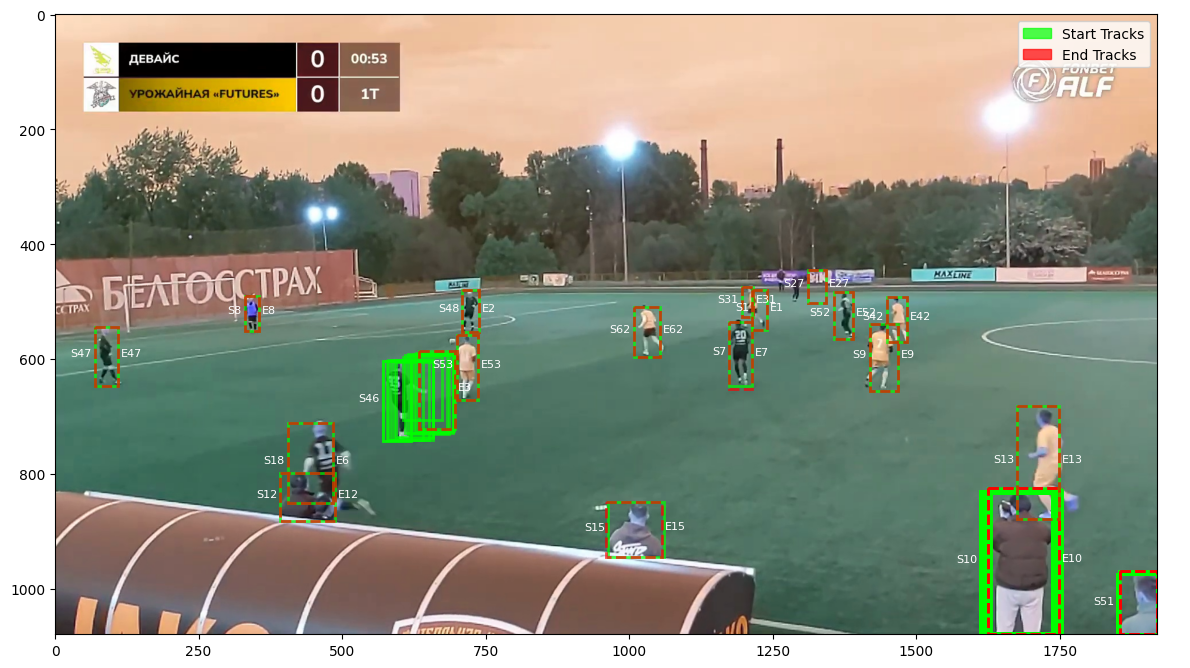

In [20]:
bkg_image_id = abs(best_start_window - best_end_window-1)
bkg_img = cv.imread(f"F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1\\{bkg_image_id:06d}.jpg")
draw_bboxes(bkg_img, best_start_bboxes, best_end_bboxes, test_mapping)

In [55]:
IMAGES_DIR0 = "F:\\Dataset\\test_merge_videos_tracklets\\part1\\outputs\\seq_0\\img1"
IMAGES_DIR1 = "F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1"
OUTPUT_PATH = "F:\\Dataset\\test_merge_videos_tracklets\\result_videos\\seq_mapped.txt"

In [ ]:
def save_results(sct_output_path, tracklets):
    """
    Saves the final tracklet results into a specified path.

    Args:
        sct_output_path (str): Path where the results will be saved.
        tracklets (dict): Dictionary of tracklets containing their final states.

    """
    results = []

    for i, tid in enumerate(sorted(tracklets.keys())): # add each track to results
        track = tracklets[tid]
        # tid = i + 1
        for instance_idx, frame_id in enumerate(track.times):
            bbox = track.bboxes[instance_idx]
            
            results.append(
                [frame_id, tid, bbox[0], bbox[1], bbox[2], bbox[3], 1, -1, -1, -1]
            )
    results = sorted(results, key=lambda x: x[0])
    txt_results = []
    for line in results:
        txt_results.append(
            f"{line[0]},{line[1]},{line[2]:.2f},{line[3]:.2f},{line[4]:.2f},{line[5]:.2f},{line[6]},{line[7]},{line[8]},{line[9]}\n"
            )
    
    # NOTE: uncomment to save results
    with open(sct_output_path, 'w') as f:
        f.writelines(txt_results)
    logger.info(f"save SCT results to {sct_output_path}")

In [52]:
save_results(OUTPUT_PATH, tracklets_spartial[1]['tracklets'])

2025-07-24 14:25:47.227 | INFO     | __main__:save_results:31 - save SCT results to F:\Dataset\test_merge_videos_tracklets\result_videos\seq_mapped.txt


In [69]:
def draw_mot_tracklets_to_video(
    tracklets,
    img_folder,
    output_video_path,
    box_color_fn=None,
    thickness=1,
    font_scale=0.5,
    frame_rate=15
):
    # Create frame_bboxes dictionary
    frame_bboxes = defaultdict(list)
    for track_id, track in tracklets.items():
        for instance_idx, frame_id in enumerate(track.times):
            bbox = track.bboxes[instance_idx]            
            frame_bboxes[frame_id].append(
                [track_id, bbox[0], bbox[1], bbox[2], bbox[3]]
            )
    
    # Get sorted list of image files from directory
    img_files = sorted([
        f for f in os.listdir(img_folder) 
        if f.endswith(('.jpg', '.png'))
    ])

    # Read first frame to get size
    first_frame = cv2.imread(os.path.join(img_folder, img_files[0]))
    if first_frame is None:
        raise ValueError("Could not read first image.")
    height, width = first_frame.shape[:2]

    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  
    video_writer = cv2.VideoWriter(output_video_path, fourcc, frame_rate, (width, height))

    # Process each frame
    for img_name in img_files:
        frame_id = float(os.path.splitext(img_name)[0])
        img_path = os.path.join(img_folder, img_name)
        frame = cv2.imread(img_path)
        
        if frame is None:
            print(f"Warning: Could not read {img_path}")
            continue

        # Draw boxes for this frame
        if frame_id in frame_bboxes:
            for track_id, x, y, w, h in frame_bboxes[frame_id]:
                color = box_color_fn(track_id) if box_color_fn else (0, 255, 0)
                x, y, w, h = int(x), int(y), int(w), int(h)
                cv2.rectangle(frame, (x, y), (x + w, y + h), color, thickness)
                cv2.putText(frame, f'ID {int(track_id)}', (x, y - 5), 
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, thickness)

        video_writer.write(frame)

    video_writer.release()
    print(f"Video saved to: {output_video_path}")

In [74]:
IMG_DIR = "F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1"
OUTPUT_VIDEO_PATH =  "F:\\Dataset\\test_merge_videos_tracklets\\result_videos\\video_2.mp4"

In [75]:
draw_mot_tracklets_to_video(
    tracklets_spartial[1]['tracklets'],
    # new_tracklets_dict['tracklets'],
    IMG_DIR,
    OUTPUT_VIDEO_PATH, 
)

Video saved to: F:\Dataset\test_merge_videos_tracklets\result_videos\video_2.mp4


In [81]:
# bboxes0 = []
# window = 1
# max_delta = tracklets_spartial[0]['time_delta'] - window

# for track_id, tracklet in tracklets_spartial[0]['tracklets'].items():
#     ids = np.ma.masked_less_equal(tracklet.times, max_delta)
#     print(ids.mask)
#     for row in ids.compressed():
#         print(row)
   
#     # if ids.shape[0] > 0:
#     #     bboxes0.append(np.asarray(tracklet.bboxes)[ids])

#     # print(tracklet.bboxes[ids])
# # bboxes0 = np.vstack(bboxes0)

In [19]:
len(tracklets_spartial[0]['tracklets']), len(tracklets_spartial[1]['tracklets'])

(64, 72)

In [151]:
bboxes0 = {}
window = 1
max_delta = tracklets_spartial[0]['time_delta'] - window
print(type(max_delta))
for track_id, tracklet in tracklets_spartial[0]['tracklets'].items():
    ids = np.nonzero(tracklet.times > max_delta)[0]
    # print(ids)
    if ids.shape[0] > 0:
        if track_id not in bboxes0:
            bboxes0[track_id] = np.asarray(tracklet.bboxes)[ids]
        else:
            bboxes0[track_id] = np.vstack((bboxes0[track_id], np.asarray(tracklet.bboxes)[ids]))       
# print(tracklet.bboxes[ids])
# bboxes0 = np.vstack(bboxes0)
# tracklet.times > (tracklets_spartial[0]['time_delta'] - window)

<class 'numpy.float64'>


In [155]:
bboxes0

{7.0: array([[1174.5 ,  534.95,   38.91,  111.5 ]]),
 8.0: array([[330.32, 489.56,  24.39,  62.31]]),
 42.0: array([[1448.76,  492.54,   35.61,   77.12]]),
 46.0: array([[570.55, 602.66,  50.35, 140.06]]),
 47.0: array([[ 68.89, 544.69,  40.33, 101.87]]),
 52.0: array([[1356.5 ,  483.76,   34.02,   80.95]]),
 53.0: array([[699.33, 558.48,  37.62, 113.1 ]]),
 9.0: array([[1418.93,  538.26,   49.01,  117.07]]),
 10.0: array([[1612.14,  830.71,  124.86,  247.78]]),
 12.0: array([[391.64, 798.49,  95.85,  83.86]]),
 13.0: array([[1676.52,  681.74,   71.73,  197.47]]),
 15.0: array([[963.48, 849.71,  97.47,  95.88]]),
 18.0: array([[405.33, 711.35,  78.71, 138.6 ]]),
 51.0: array([[1850.8 ,  974.57,   68.2 ,  104.43]]),
 62.0: array([[1008.03,  508.47,   46.4 ,   88.02]]),
 31.0: array([[1196.12,  475.04,   18.98,   51.56]])}

In [156]:
bboxes1 = {}
window = 15
max_delta = np.float64(window)
for track_id, tracklet in tracklets_spartial[1]['tracklets'].items():
    ids = np.nonzero(tracklet.times < max_delta)[0][-1:]
    # print(ids)
    if ids.shape[0] > 0:
        if track_id not in bboxes1:
            bboxes1[track_id] = np.asarray(tracklet.bboxes)[ids]
        else:
            bboxes1[track_id] = np.vstack((bboxes1[track_id], np.asarray(tracklet.bboxes)[ids])) 
        
# bboxes1 = np.vstack(bboxes1)        

In [157]:
bboxes1

{1.0: array([[381.94, 710.36,  65.83, 143.48]]),
 2.0: array([[1172.05,  536.55,   42.64,  109.67]]),
 3.0: array([[702.52, 548.7 ,  36.18, 121.85]]),
 4.0: array([[ 61.63, 542.09,  34.21, 103.76]]),
 5.0: array([[1448.76,  492.54,   35.61,   77.12]]),
 6.0: array([[1214.09,  480.35,   26.89,   69.59]]),
 7.0: array([[709.29, 480.43,  29.48,  71.64]]),
 48.0: array([[1609.68,  829.69,  122.27,  248.5 ]]),
 49.0: array([[1624.61,  824.09,  123.88,  254.46]]),
 50.0: array([[1425.23,  538.31,   46.26,  116.  ]]),
 53.0: array([[634.1 , 585.95,  61.81, 135.78]]),
 55.0: array([[998.18, 509.46,  45.32,  86.97]]),
 57.0: array([[963.64, 850.54,  97.31,  95.75]]),
 58.0: array([[329.86, 489.31,  24.25,  64.68]]),
 59.0: array([[391.64, 798.49,  95.85,  83.86]]),
 52.0: array([[564.61, 606.04,  54.85, 138.3 ]]),
 54.0: array([[1850.41,  975.09,   68.59,  103.91]]),
 60.0: array([[1346.03,  484.43,   36.79,   78.31]]),
 8.0: array([[1659.13,  674.96,   83.02,  204.55]]),
 9.0: array([[1311.16,

In [164]:
distance = np.zeros((len(bboxes0), len(bboxes1)))
overlap = np.zeros((len(bboxes0), len(bboxes1)))

# Get sorted lists of keys for consistent indexing
keys0 = sorted(bboxes0.keys())
keys1 = sorted(bboxes1.keys())

# Create mapping from key to index
key_to_idx0 = {key: i for i, key in enumerate(keys0)}
key_to_idx1 = {key: i for i, key in enumerate(keys1)}

for key0, bbox0 in bboxes0.items():
    for key1, bbox1 in bboxes1.items():
        i = key_to_idx0[key0]
        j = key_to_idx1[key1]
        distance[i,j] = calculate_bbox_distance(bbox0[0], bbox1[0])  # Take first bbox if multiple
        overlap[i,j] = calculate_bbox_overlap(bbox0[0], bbox1[0])    # Take first bbox if multiple

In [165]:
np.argmax(overlap, axis=1)

array([ 1, 18, 12, 10, 19,  7, 17,  0,  9,  4, 13,  3, 15, 20,  2, 16],
      dtype=int64)

<Axes: >

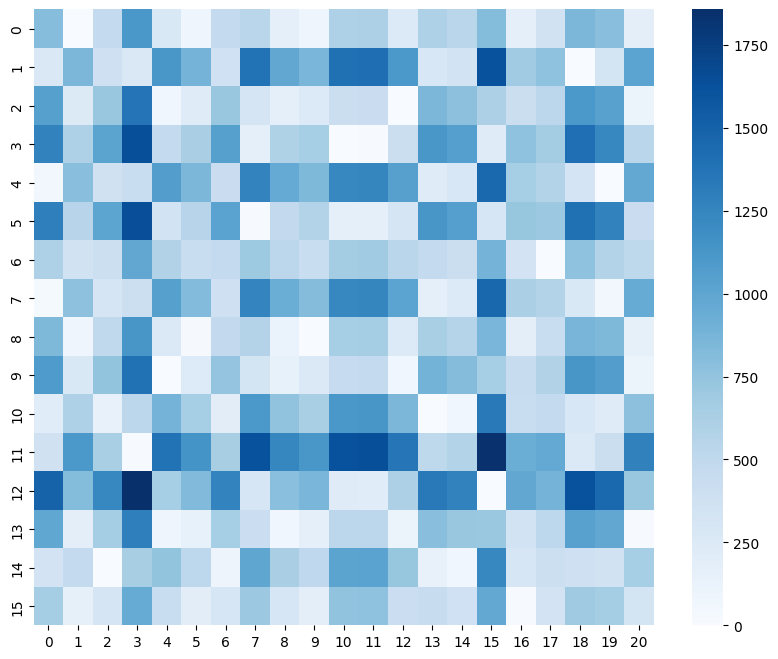

In [166]:
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(distance, cmap='Blues')

<Axes: >

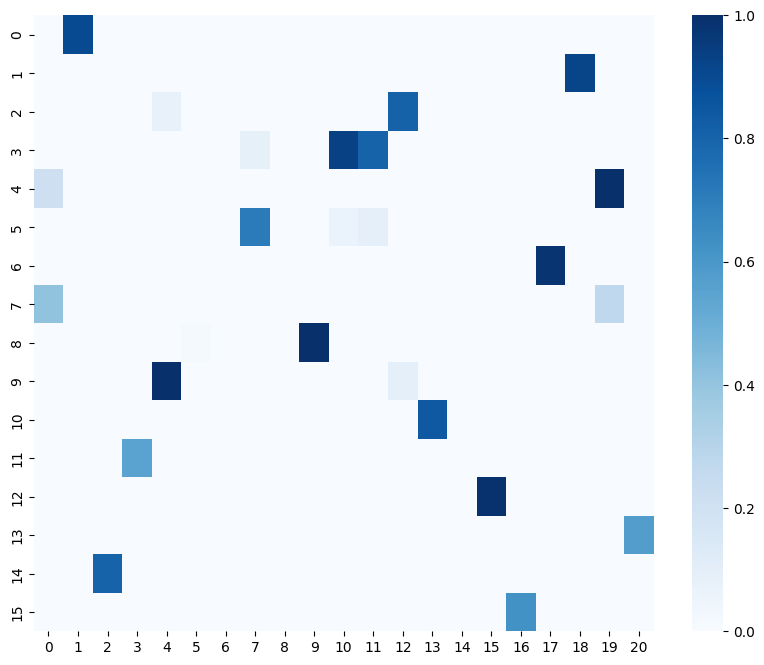

In [167]:
plt.figure(figsize=(10, 8))  # Optional: adjust the size of the heatmap
# Plot the heatmap
sns.heatmap(overlap, cmap='Blues')

In [31]:
bboxes0.shape, bboxes1.shape

((16, 4), (21, 4))

In [32]:
back_img1 = cv.imread("F:\\Dataset\\test_merge_videos_tracklets\\part1\\outputs\\seq_0\\img1\\001767.jpg")
back_img2 = [cv.imread(f"F:\\Dataset\\test_merge_videos_tracklets\\part2\\outputs\\seq_0\\img1\\{i:06d}.jpg") for i in range(5,15)]

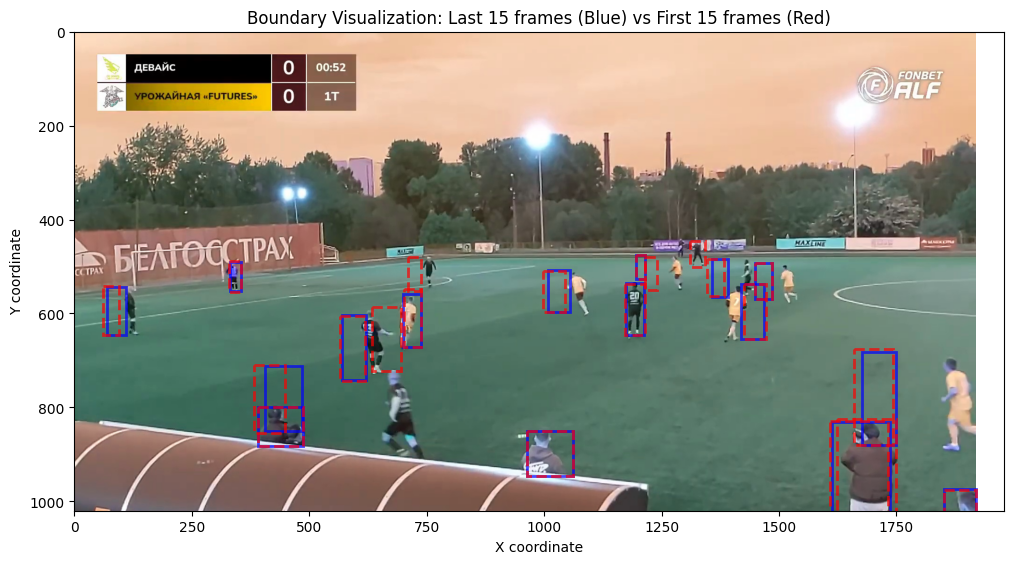

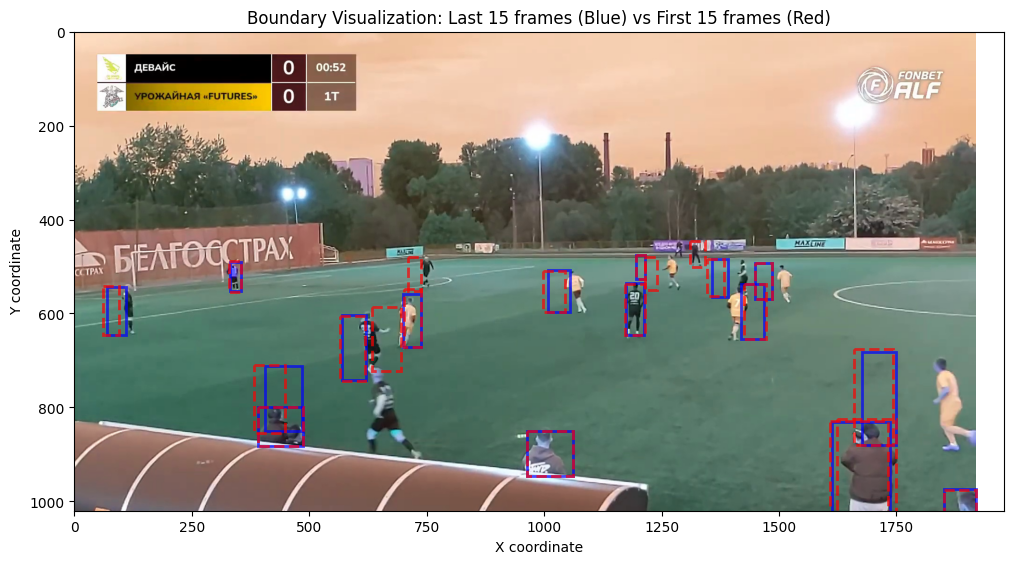

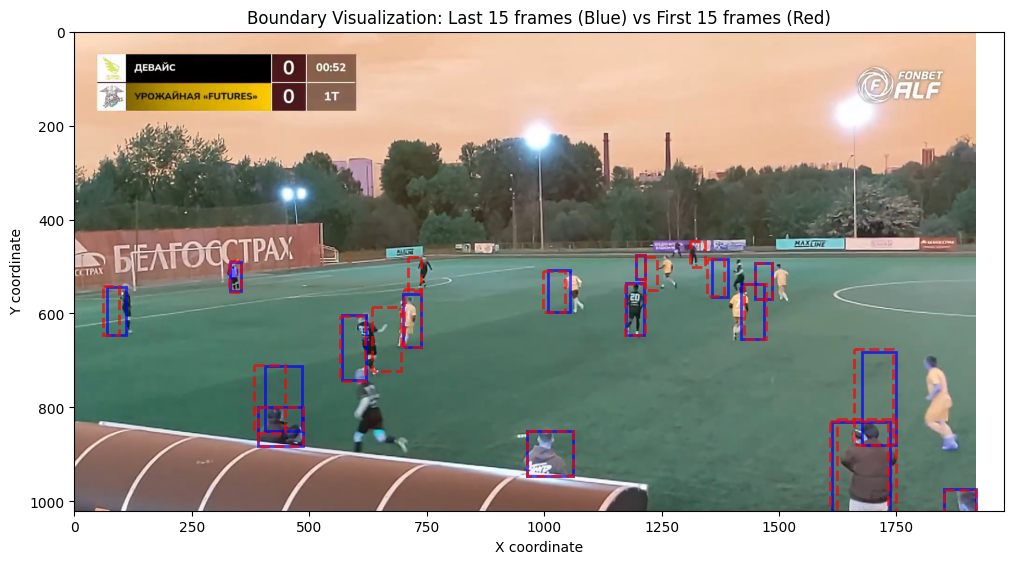

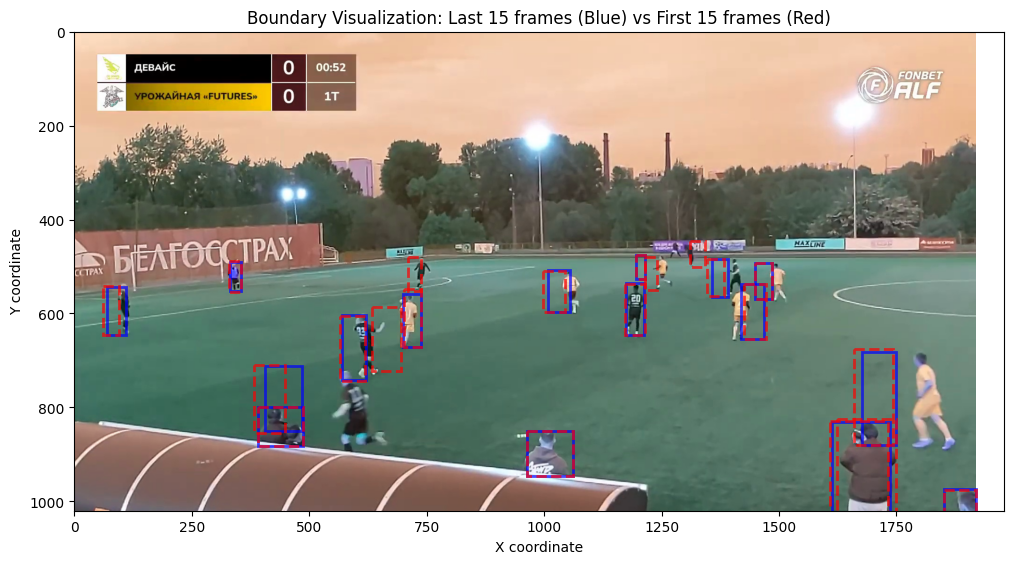

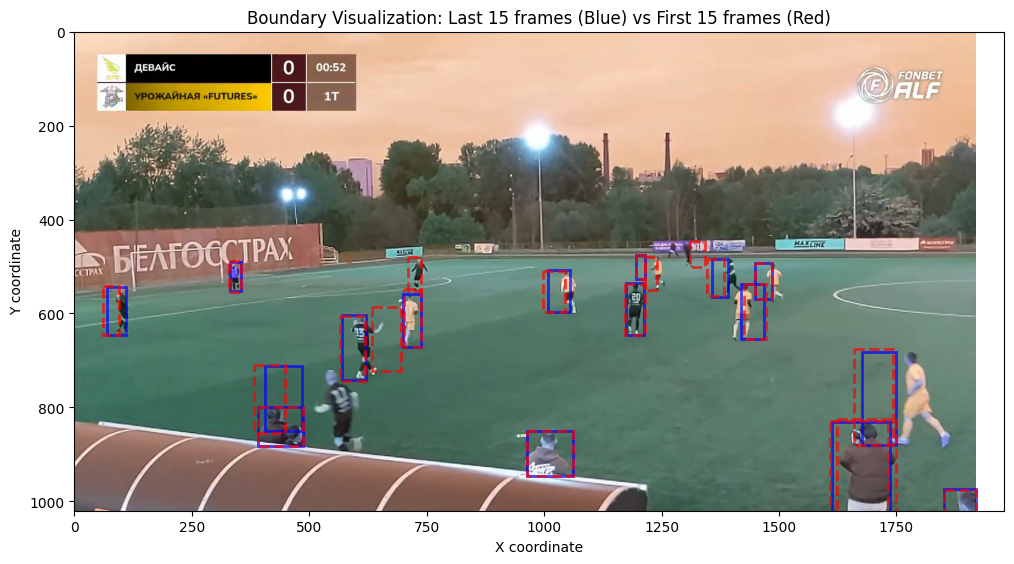

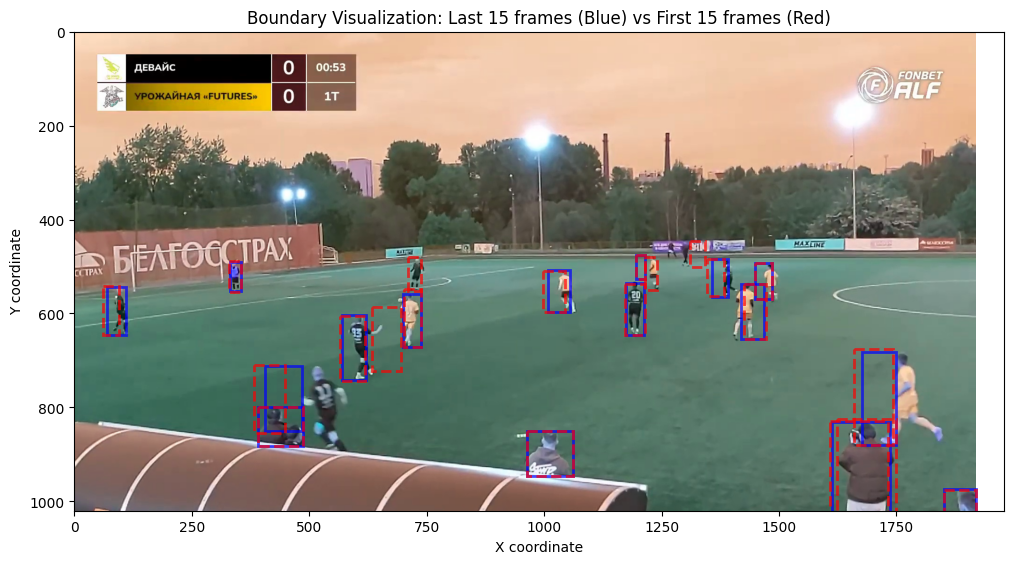

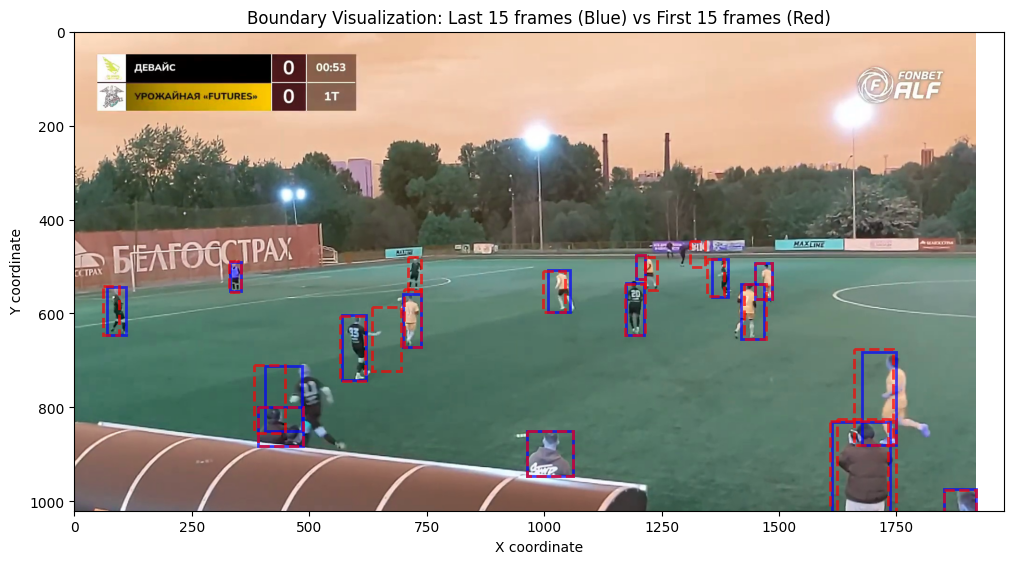

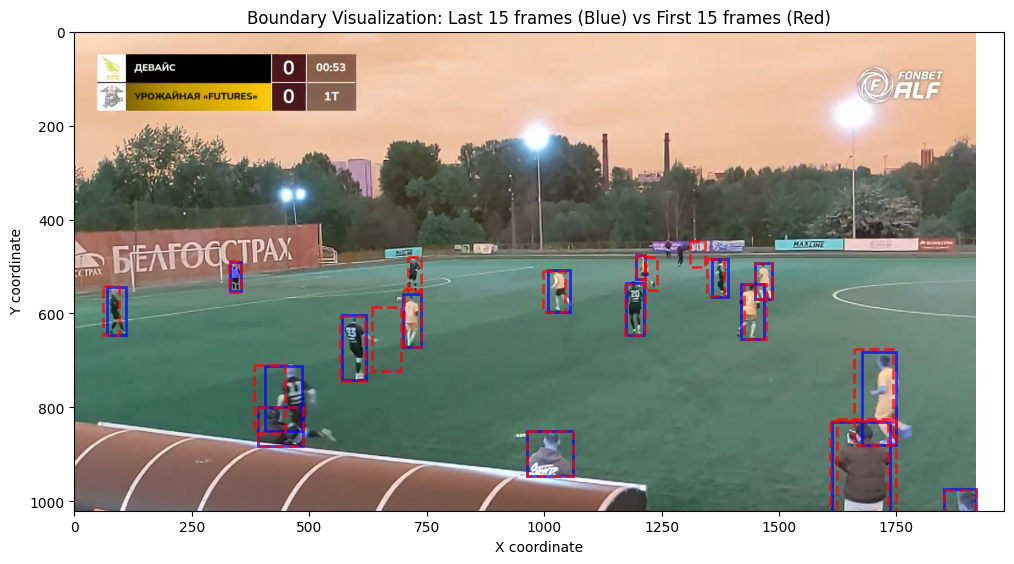

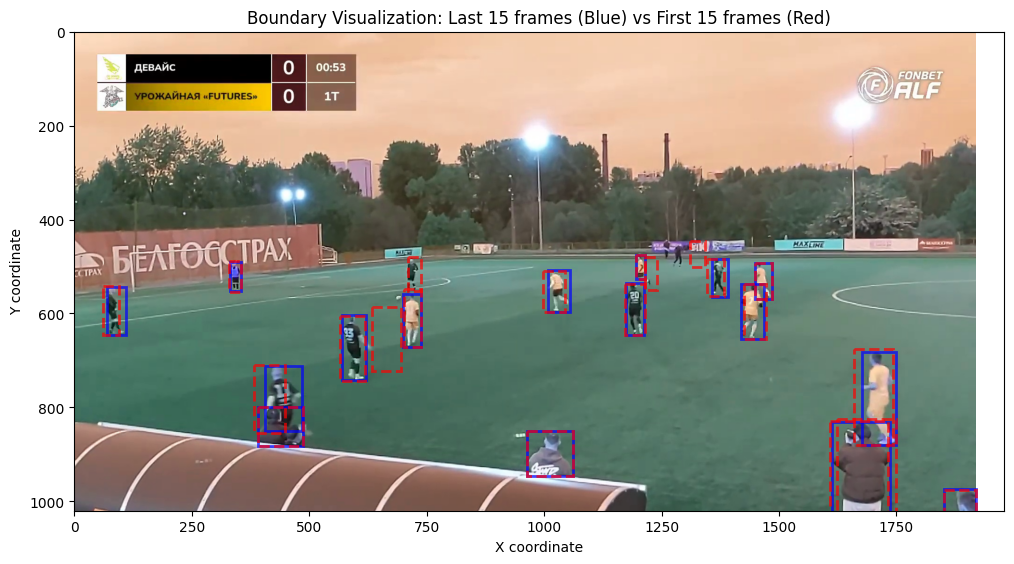

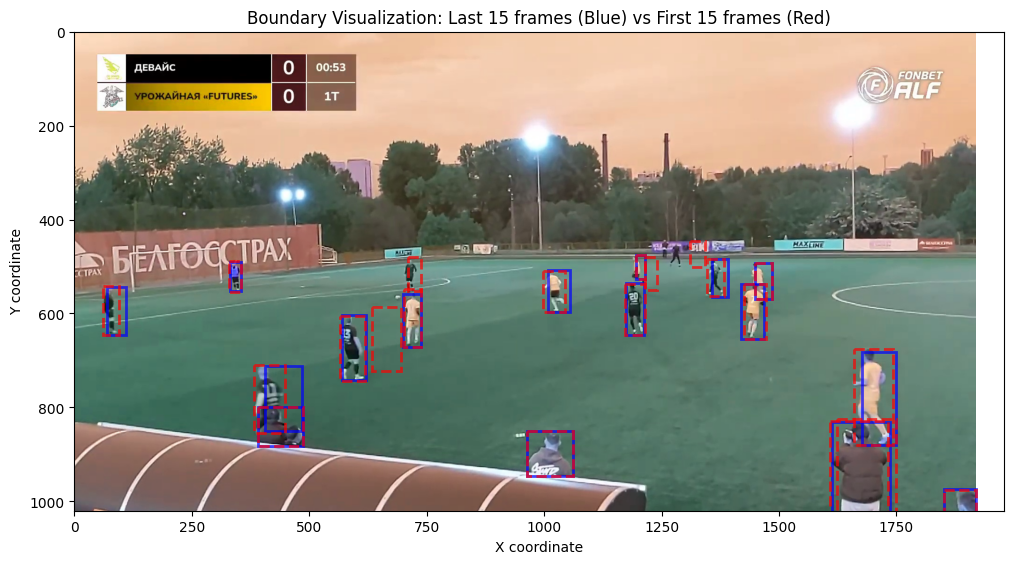

In [33]:
for back_img in back_img2:
    fig, ax = plt.subplots(figsize=(12, 8))
    image_size = (1980, 1020)
    # Set plot limits
    ax.set_xlim(0, image_size[0])
    ax.set_ylim(image_size[1], 0)  # Invert y-axis for image coordinates
    ax.set_title(f"Boundary Visualization: Last {window} frames (Blue) vs First {window} frames (Red)")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.imshow(back_img)
    # Draw bboxes from first video (end)
    for bbox in bboxes0:
        x, y, w, h = bbox
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=2, edgecolor='blue', facecolor='none', 
            linestyle='-', alpha=0.7
        )
        ax.add_patch(rect)
        
    # Draw bboxes from second video (start)
    for bbox in bboxes1:
        x, y, w, h = bbox
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=2, edgecolor='red', facecolor='none', 
            linestyle='--', alpha=0.7
        )
        ax.add_patch(rect)

    plt.show()

In [ ]:
def display_boundary_bboxes(tracklets1, tracklets2, window=1, image_size=None):
    """
    Displays bounding boxes at the end of the first video and start of the second video.
    
    Parameters:
    tracklets1 (dict): Tracklets from first video {track_id: Tracklet}
    tracklets2 (dict): Tracklets from second video {track_id: Tracklet}
    window (int): Number of frames to consider at the boundary
    image_size (tuple): (width, height) of the image. If None, auto-calculated.
    """
    # Find maximum frame in first video
    max_frame1 = 0
    for tr in tracklets1.values():
        if tr.times:
            current_max = max(tr.times)
            if current_max > max_frame1:
                max_frame1 = current_max

    # Collect boundary bboxes from first video
    end_bboxes1 = []
    for tr in tracklets1.values():
        if tr.times and tr.bboxes:
            # Check if tracklet ends in the boundary window
            if max(tr.times) >= max_frame1 - window + 1:
                # Get last bbox
                end_bboxes1.append(tr.bboxes[-1])
    
    # Collect boundary bboxes from second video
    start_bboxes2 = []
    for tr in tracklets2.values():
        if tr.times and tr.bboxes:
            # Check if tracklet starts in the boundary window
            if min(tr.times) <= window:
                # Get first bbox
                start_bboxes2.append(tr.bboxes[0])
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Determine image size if not provided
    if image_size is None:
        all_bboxes = end_bboxes1 + start_bboxes2
        if not all_bboxes:
            print("No boundary boxes found")
            return
        max_x = max(bbox[0] + bbox[2] for bbox in all_bboxes)
        max_y = max(bbox[1] + bbox[3] for bbox in all_bboxes)
        image_size = (max_x + 50, max_y + 50)  # Add padding
    
    # Set plot limits
    ax.set_xlim(0, image_size[0])
    ax.set_ylim(image_size[1], 0)  # Invert y-axis for image coordinates
    ax.set_title(f"Boundary Visualization: Last {window} frames (Blue) vs First {window} frames (Red)")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    
    # Draw bboxes from first video (end)
    for bbox in end_bboxes1:
        x, y, w, h = bbox
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=2, edgecolor='blue', facecolor='none', 
            linestyle='-', alpha=0.7
        )
        ax.add_patch(rect)
    
    # Draw bboxes from second video (start)
    for bbox in start_bboxes2:
        x, y, w, h = bbox
        rect = patches.Rectangle(
            (x, y), w, h, 
            linewidth=2, edgecolor='red', facecolor='none', 
            linestyle='--', alpha=0.7
        )
        ax.add_patch(rect)
    
    # Create legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', lw=2, label=f'End of First Video (Last {window} frames)'),
        Line2D([0], [0], color='red', lw=2, label=f'Start of Second Video (First {window} frames)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.grid(linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
def find_tracklet_correspondence(tracklets_video1: Dict[int, Tracklet], 
                               tracklets_video2: Dict[int, Tracklet],
                               distance_threshold: float = 50.0,
                               overlap_threshold: float = 0.1,
                               time_window: int = 5) -> Dict[int, int]:
    """
    Find correspondence between tracklets from two consecutive videos
    
    Args:
        tracklets_video1: Dictionary of tracklets from first video
        tracklets_video2: Dictionary of tracklets from second video
        distance_threshold: Maximum distance between bbox centers to consider correspondence
        overlap_threshold: Minimum IoU to consider correspondence
        time_window: Number of frames to look at from end of video1 and start of video2
    
    Returns:
        Dictionary mapping tracklet_id from video1 to tracklet_id from video2
    """
    correspondence_map = {}
    
    for id1, tracklet1 in tracklets_video1.items():
        if not tracklet1.times:
            continue
            
        # Get the last few bounding boxes from video1
        end_indices = max(0, len(tracklet1.times) - time_window)
        end_bboxes1 = tracklet1.bboxes[end_indices:]
        
        best_match_id = None
        best_score = 0
        
        for id2, tracklet2 in tracklets_video2.items():
            if not tracklet2.times:
                continue
                
            # Get the first few bounding boxes from video2
            start_bboxes2 = tracklet2.bboxes[:min(time_window, len(tracklet2.bboxes))]
            
            # Calculate similarity scores between end of tracklet1 and start of tracklet2
            total_score = 0
            comparisons = 0
            
            for bbox1 in end_bboxes1:
                for bbox2 in start_bboxes2:
                    distance = calculate_bbox_distance(bbox1, bbox2)
                    overlap = calculate_bbox_overlap(bbox1, bbox2)
                    
                    if distance < distance_threshold and overlap > overlap_threshold:
                        # Combine distance and overlap into a single score
                        score = overlap * (1 - distance / distance_threshold)
                        total_score += score
                        comparisons += 1
            
            if comparisons > 0:
                avg_score = total_score / comparisons
                if avg_score > best_score:
                    best_score = avg_score
                    best_match_id = id2
        
        if best_match_id is not None and best_score > 0.1:  # Minimum confidence threshold
            correspondence_map[id1] = best_match_id
    
    return correspondence_map

In [48]:
find_tracklet_correspondence(tracklets_spartial[0]['tracklets'], tracklets_spartial[1]['tracklets'])

{}

In [51]:
tracklets_spartial[0]['tracklets'].items()

dict_items([(1.0, <Tracklet.Tracklet object at 0x000001AC60F4A810>), (2.0, <Tracklet.Tracklet object at 0x000001AC610E7B30>), (3.0, <Tracklet.Tracklet object at 0x000001AC611B7DD0>), (4.0, <Tracklet.Tracklet object at 0x000001AC612EE930>), (5.0, <Tracklet.Tracklet object at 0x000001AC614341D0>), (6.0, <Tracklet.Tracklet object at 0x000001AC616A88F0>), (7.0, <Tracklet.Tracklet object at 0x000001AC6144FE60>), (8.0, <Tracklet.Tracklet object at 0x000001AC61496900>), (42.0, <Tracklet.Tracklet object at 0x000001AC61530320>), (44.0, <Tracklet.Tracklet object at 0x000001AC61B1B800>), (46.0, <Tracklet.Tracklet object at 0x000001AC62B644A0>), (47.0, <Tracklet.Tracklet object at 0x000001AC62BAC5C0>), (48.0, <Tracklet.Tracklet object at 0x000001AC62CA2960>), (49.0, <Tracklet.Tracklet object at 0x000001AC62CD7D40>), (50.0, <Tracklet.Tracklet object at 0x000001AC62E01A60>), (52.0, <Tracklet.Tracklet object at 0x000001AC62F67680>), (53.0, <Tracklet.Tracklet object at 0x000001AC62FF1EE0>), (9.0, <Tra

In [86]:
correspondence_map = {}
time_window = 20
distance_threshold: float = 200.0
overlap_threshold: float = 0.01
for id1, tracklet1 in tracklets_spartial[0]['tracklets'].items():
    if not tracklet1.times:
        continue
        
    # Get the last few bounding boxes from video1
    end_indices = max(0, len(tracklet1.times) - time_window)
    end_bboxes1 = tracklet1.bboxes[end_indices:]
    
    best_match_id = None
    best_score = 0.0
    
    for id2, tracklet2 in tracklets_spartial[1]['tracklets'].items():
        if not tracklet2.times:
            continue
            
        # Get the first few bounding boxes from video2
        start_bboxes2 = tracklet2.bboxes[:min(time_window, len(tracklet2.bboxes))]
        
        # Calculate similarity scores between end of tracklet1 and start of tracklet2
        total_score = 0
        comparisons = 0
        for bbox1 in end_bboxes1:
            for bbox2 in start_bboxes2:
                distance = calculate_bbox_distance(bbox1, bbox2)
                overlap = calculate_bbox_overlap(bbox1, bbox2)
                # print(f"bbox1: {bbox1}, bbox2: {bbox2}, distance: {distance}, overlap: {overlap}")
                if distance < distance_threshold and overlap > overlap_threshold:
                    # Combine distance and overlap into a single score
                    score = overlap * (1 - distance / distance_threshold)
                    total_score += score
                    comparisons += 1
        
        if comparisons > 0:
            avg_score = total_score / comparisons
            print(f"{id1} vs {id2}: best_score={best_score}, avg_score={avg_score}")            
            if avg_score > best_score:
                best_score = avg_score
                best_match_id = id2

    if best_match_id is not None and best_score > 0.0001:  # Minimum confidence threshold
        correspondence_map[id1] = best_match_id        

45.0 vs 5.0: best_score=0.0, avg_score=0.0010681537552968932
45.0 vs 60.0: best_score=0.0010681537552968932, avg_score=0.0008125130299658516
45.0 vs 11.0: best_score=0.0010681537552968932, avg_score=0.0010387377225526693
45.0 vs 63.0: best_score=0.0010681537552968932, avg_score=0.0008401893709040182
45.0 vs 19.0: best_score=0.0010681537552968932, avg_score=0.0012351023145714258
45.0 vs 70.0: best_score=0.0012351023145714258, avg_score=0.0009199106938535367
26.0 vs 33.0: best_score=0.0, avg_score=0.0002003956576335869
26.0 vs 34.0: best_score=0.0002003956576335869, avg_score=0.00030523822066357703
34.0 vs 18.0: best_score=0.0, avg_score=4.754922540666404e-05
34.0 vs 28.0: best_score=4.754922540666404e-05, avg_score=0.00028782765872126275
34.0 vs 39.0: best_score=0.00028782765872126275, avg_score=0.0006570109586302987
36.0 vs 9.0: best_score=0.0, avg_score=8.546978712798037e-05
38.0 vs 26.0: best_score=0.0, avg_score=0.0007078012945208013


In [87]:
correspondence_map

{45.0: 19.0, 26.0: 34.0, 34.0: 39.0, 38.0: 26.0}